In [ ]:
import pandas as pd
import numpy as np
import torch

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [ ]:
columns = ["ID", "entity", "sentiment", "text"]

train_df  = pd.read_csv("/content/twitter_training.csv", header=None, names=columns)
val_df  = pd.read_csv("/content/twitter_validation.csv", header=None, names=columns)

Preprocessing

In [ ]:
#Check shape and columns
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

print("\nTrain columns:", train_df.columns)
print("Validation columns:", val_df.columns)

Train shape: (74682, 4)
Validation shape: (1000, 4)

Train columns: Index(['ID', 'entity', 'sentiment', 'text'], dtype='object')
Validation columns: Index(['ID', 'entity', 'sentiment', 'text'], dtype='object')


In [ ]:
print("\nMissing values in TRAIN:")
print(train_df.isna().sum())

print("\nMissing values in VALIDATION:")
print(val_df.isna().sum())


Missing values in TRAIN:
ID             0
entity         0
sentiment      0
text         686
dtype: int64

Missing values in VALIDATION:
ID           0
entity       0
sentiment    0
text         0
dtype: int64


In [ ]:
#Remove null texts

train_df = train_df.dropna(subset=["text"])

print("\nMissing values in TRAIN:")
print(train_df.isna().sum())

print("\nMissing values in VALIDATION:")
print(val_df.isna().sum())


Missing values in TRAIN:
ID           0
entity       0
sentiment    0
text         0
dtype: int64

Missing values in VALIDATION:
ID           0
entity       0
sentiment    0
text         0
dtype: int64


In [ ]:
#Remove irrelevant sentiments

VALID_SENTIMENTS = ["Negative", "Neutral", "Positive"]
train_df = train_df[train_df["sentiment"].isin(VALID_SENTIMENTS)]
val_df   = val_df[val_df["sentiment"].isin(VALID_SENTIMENTS)]

print("\nTrain sentiment distribution after filtering:")
print(train_df["sentiment"].value_counts())

print("\nValidation sentiment distribution after filtering:")
print(val_df["sentiment"].value_counts())


Train sentiment distribution after filtering:
sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64

Validation sentiment distribution after filtering:
sentiment
Neutral     285
Positive    277
Negative    266
Name: count, dtype: int64


In [ ]:
#Check that there are no duplicates in both datasets

train_texts = set(train_df["text"].astype(str))
val_texts = set(val_df["text"].astype(str))

overlap = train_texts.intersection(val_texts)

print("Number of overlapping texts:", len(overlap))

Number of overlapping texts: 431


In [ ]:
# Normalize text to catch near-duplicates
def normalize_text(t):
    return " ".join(str(t).lower().split())

train_df["text_norm"] = train_df["text"].apply(normalize_text)
val_df["text_norm"]   = val_df["text"].apply(normalize_text)

train_norm_set = set(train_df["text_norm"])
val_norm_set   = set(val_df["text_norm"])

overlap_norm = train_norm_set.intersection(val_norm_set)

print("Number of overlapping texts (normalized):", len(overlap_norm))

Number of overlapping texts (normalized): 431


In [ ]:
#Remove overlaps from training only
train_df = train_df[~train_df["text_norm"].isin(overlap_norm)]

print("Train size after removing overlaps:", len(train_df))
print("Validation size (unchanged):", len(val_df))

Train size after removing overlaps: 60462
Validation size (unchanged): 828


In [ ]:
train_df = train_df.drop(columns=["text_norm"])
val_df   = val_df.drop(columns=["text_norm"])

Final Dataset Analysis


Final TRAIN shape: (60462, 4)
Final VALIDATION shape: (828, 4)


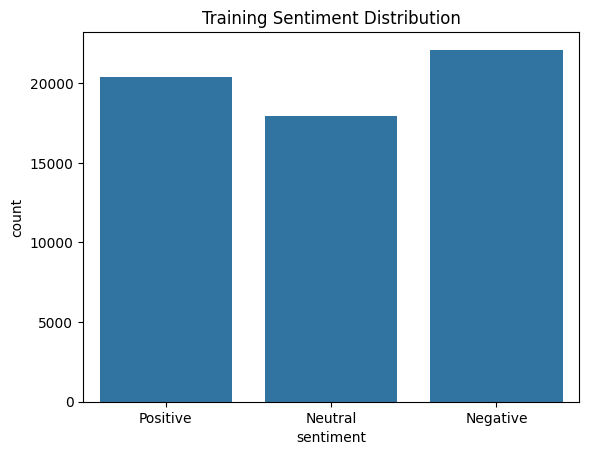

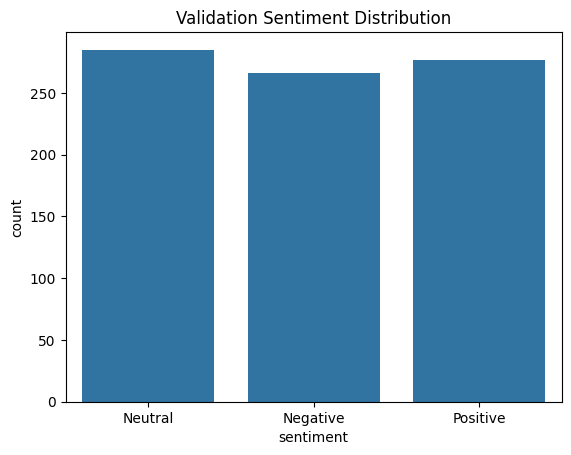

In [ ]:
print("\nFinal TRAIN shape:", train_df.shape)
print("Final VALIDATION shape:", val_df.shape)

sns.countplot(x='sentiment', data=train_df)
plt.title("Training Sentiment Distribution")
plt.show()

sns.countplot(x='sentiment', data=val_df)
plt.title("Validation Sentiment Distribution")
plt.show()

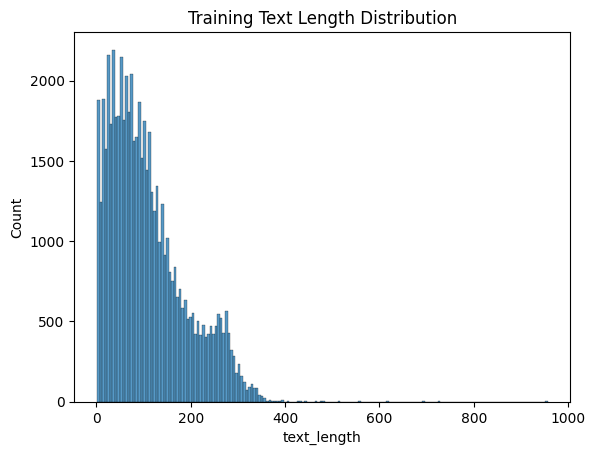

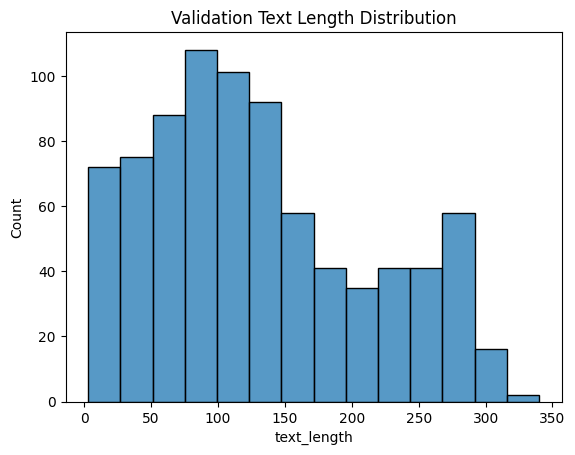

In [ ]:
train_df['text_length'] = train_df['text'].apply(len)
sns.histplot(train_df['text_length'])
plt.title("Training Text Length Distribution")
plt.show()

val_df['text_length'] = val_df['text'].apply(len)
sns.histplot(val_df['text_length'])
plt.title("Validation Text Length Distribution")
plt.show()

Train Test Splitting

In [ ]:
#Merge both datasets because the validation set is small

full_df = pd.concat([train_df, val_df], ignore_index=True)

print("Merged dataset shape:", full_df.shape)

Merged dataset shape: (61290, 4)


In [ ]:
# Ensure no nulls
full_df = full_df.dropna(subset=["text", "sentiment"])

# Normalize sentiment text (safety)
full_df["sentiment"] = (
    full_df["sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(full_df["sentiment"].value_counts())

sentiment
negative    22370
positive    20662
neutral     18258
Name: count, dtype: int64


In [ ]:
X = full_df["text"].values
y = full_df["sentiment"].values

# 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Split temp into validation and test (10% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 49032
Validation: 6129
Test: 6129


In [ ]:
#Encode labels

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc   = label_encoder.transform(y_val)
y_test_enc  = label_encoder.transform(y_test)

print("Label mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Label mapping:
0 -> negative
1 -> neutral
2 -> positive


SVM Model

In [ ]:
#TF-IDF Feature Extraction
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True,
    strip_accents="unicode"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (49032, 48245)


In [ ]:
svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train_enc)

LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)

In [ ]:
y_val_pred_svm = svm_model.predict(X_val_tfidf)

print("SVM Validation Accuracy:", accuracy_score(y_val_enc, y_val_pred_svm))
print("SVM Validation Macro-F1:", f1_score(y_val_enc, y_val_pred_svm, average="macro"))

print("\nValidation Classification Report:\n")
print(classification_report(
    y_val_enc,
    y_val_pred_svm,
    target_names=label_encoder.classes_
))

SVM Validation Accuracy: 0.9223364333496492
SVM Validation Macro-F1: 0.9217665790324383

Validation Classification Report:

              precision    recall  f1-score   support

    negative       0.94      0.93      0.93      2237
     neutral       0.93      0.90      0.92      1826
    positive       0.90      0.93      0.92      2066

    accuracy                           0.92      6129
   macro avg       0.92      0.92      0.92      6129
weighted avg       0.92      0.92      0.92      6129



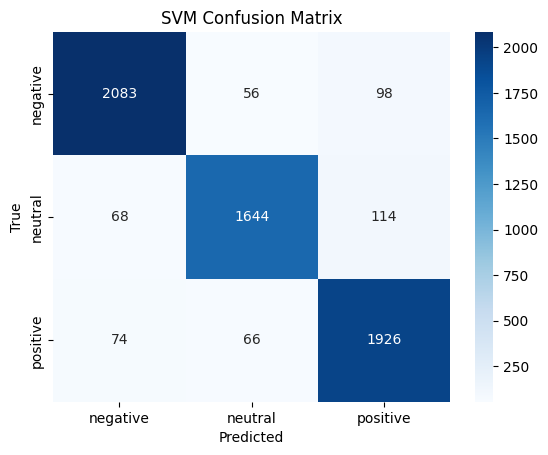

In [ ]:
cm = confusion_matrix(y_val_enc, y_val_pred_svm)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SVM Confusion Matrix")
plt.show()

LSTM Model

In [ ]:
#Tokenization and Padding

MAX_VOCAB = 30000
MAX_LEN   = 100   # good default for reviews/comments

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_val),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [ ]:
#Build LSTM Model Architecture

NUM_CLASSES = len(label_encoder.classes_)

model = Sequential([
    Embedding(
        input_dim=MAX_VOCAB,
        output_dim=128,
        input_length=MAX_LEN
    ),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/10
767/767 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.6187 - loss: 0.8195 - val_accuracy: 0.8486 - val_loss: 0.3889
Epoch 2/10
767/767 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8955 - loss: 0.2807 - val_accuracy: 0.8824 - val_loss: 0.2965
Epoch 3/10
767/767 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9293 - loss: 0.1782 - val_accuracy: 0.9026 - val_loss: 0.2645
Epoch 4/10
767/767 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9451 - loss: 0.1339 - val_accuracy: 0.9081 - val_loss: 0.2608
Epoch 5/10
767/767 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9558 - loss: 0.1089 - val_accuracy: 0.9099 - val_loss: 0.2736
Epoch 6/10
767/767 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9596 - loss: 0.0955 - val_accuracy: 0.9090 - val_loss: 0.2877


In [ ]:
y_test_pred_lstm = model.predict(X_test_seq).argmax(axis=1)

print("LSTM Test Accuracy:", accuracy_score(y_test_enc, y_test_pred_lstm))
print("LSTM Test Macro-F1:", f1_score(y_test_enc, y_test_pred_lstm, average="macro"))

print("\nTest Classification Report:\n")
print(classification_report(
    y_test_enc,
    y_test_pred_lstm,
    target_names=label_encoder.classes_
))

192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
LSTM Test Accuracy: 0.9030837004405287
LSTM Test Macro-F1: 0.9025465756537372

Test Classification Report:

              precision    recall  f1-score   support

    negative       0.91      0.92      0.91      2237
     neutral       0.94      0.86      0.90      1826
    positive       0.87      0.93      0.90      2066

    accuracy                           0.90      6129
   macro avg       0.91      0.90      0.90      6129
weighted avg       0.90      0.90      0.90      6129



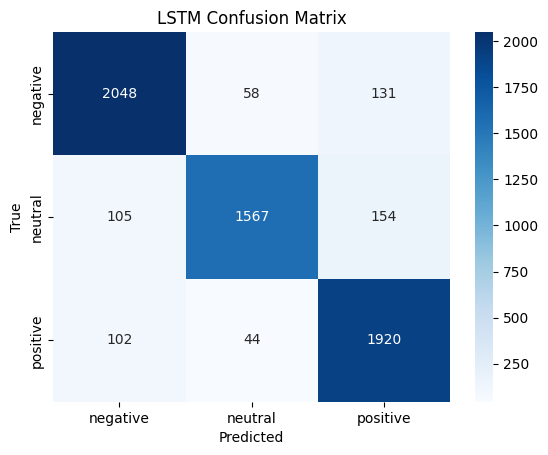

In [ ]:
cm = confusion_matrix(y_test_enc, y_test_pred_lstm)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("LSTM Confusion Matrix")
plt.show()

RoBERTa Model

In [ ]:
#Build Hugging Face datasets
train_ds = Dataset.from_dict({"text": X_train, "label": y_train_enc})
val_ds   = Dataset.from_dict({"text": X_val,   "label": y_val_enc})
test_ds  = Dataset.from_dict({"text": X_test,  "label": y_test_enc})

In [ ]:
#Tokenization
MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

train_tok = train_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
val_tok   = val_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
test_tok  = test_ds.map(tokenize_fn, batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/49032 [00:00<?, ? examples/s]

Map:   0%|          | 0/6129 [00:00<?, ? examples/s]

Map:   0%|          | 0/6129 [00:00<?, ? examples/s]

In [ ]:
#Build model architecture
NUM_CLASSES = len(label_encoder.classes_)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

In [ ]:
args = TrainingArguments(
    output_dir="roberta_sentiment",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42,
    data_seed=42
)

In [ ]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

trainer.train()

/tmp/ipython-input-2374805161.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.529200,0.493570,0.810573,0.802239
2,0.325400,0.322803,0.888563,0.887171
3,0.140600,0.348703,0.908631,0.907796


TrainOutput(global_step=9195, training_loss=0.399233711537231, metrics={'train_runtime': 1017.3299, 'train_samples_per_second': 144.59, 'train_steps_per_second': 9.038, 'total_flos': 5440046690853936.0, 'train_loss': 0.399233711537231, 'epoch': 3.0})

In [ ]:
val_metrics = trainer.evaluate(val_tok)
print("RoBERTa Validation:", val_metrics)

In [ ]:
test_pred_roberta = trainer.predict(test_tok)
test_logits = test_pred_roberta.predictions
test_labels = test_pred_roberta.label_ids
test_preds = np.argmax(test_logits, axis=1)

print("RoBERTa Test Accuracy:", accuracy_score(test_labels, test_preds))
print("RoBERTa Test Macro-F1:", f1_score(test_labels, test_preds, average="macro"))

print("\nTest Classification Report:\n")
print(classification_report(
    test_labels,
    test_preds,
    target_names=label_encoder.classes_
))

RoBERTa Test Accuracy: 0.9084679393049437
RoBERTa Test Macro-F1: 0.9073674249802918

Test Classification Report:

              precision    recall  f1-score   support

    negative       0.92      0.93      0.92      2237
     neutral       0.90      0.88      0.89      1826
    positive       0.90      0.91      0.91      2066

    accuracy                           0.91      6129
   macro avg       0.91      0.91      0.91      6129
weighted avg       0.91      0.91      0.91      6129



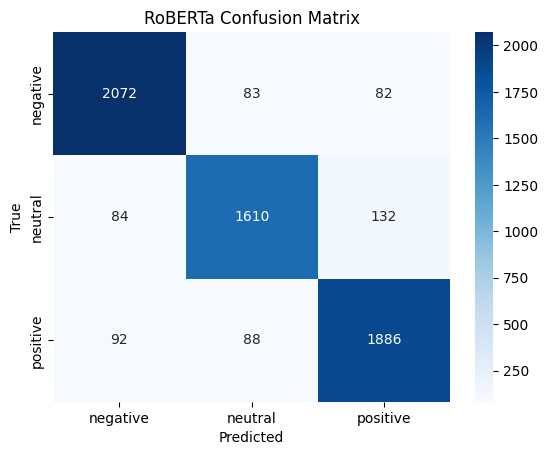

In [ ]:
cm = confusion_matrix(test_labels, test_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("RoBERTa Confusion Matrix")
plt.show()